# 1. Import Libraries

In [1973]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, FunctionTransformer, PowerTransformer

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import joblib



# 2. Load Data

In [1974]:
customers = pd.read_csv("Wholesale_customers_data.csv")

In [1975]:
customers.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [1976]:
customers.shape

(440, 8)

In [1977]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [1978]:
customers.describe().T

,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Region,440.0,2.543182,0.774272,1.0,2.00,3.0,3.00,3.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


# 3. EDA

### 3.1 Check for duplicates

In [1979]:
customers.duplicated().sum()

np.int64(0)

### 3.2 Correlation Heatmap

<Axes: >

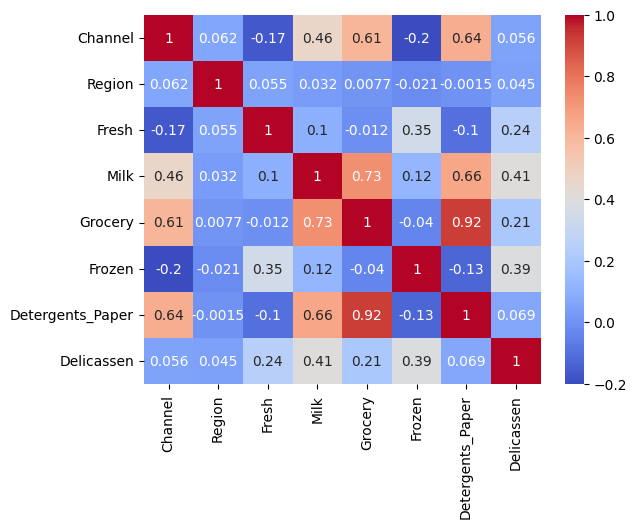

In [1980]:
customer_corr = customers.corr()
sns.heatmap(customer_corr, cmap='coolwarm', annot=True)


Channel
1    0.677273
2    0.322727
Name: proportion, dtype: float64

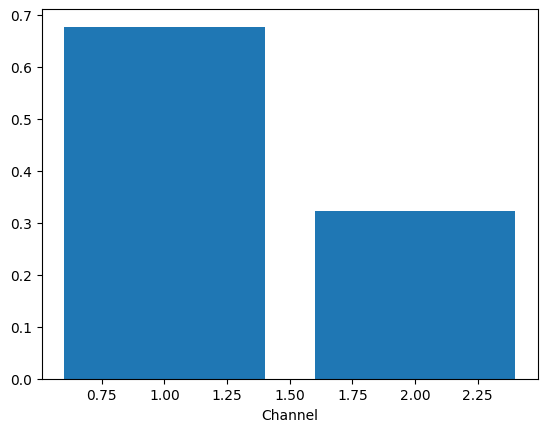

In [1981]:
count = customers["Channel"].value_counts(normalize=True)
plt.bar(count.index, count.values)
plt.xlabel("Channel")
count

Region
3    0.718182
1    0.175000
2    0.106818
Name: proportion, dtype: float64

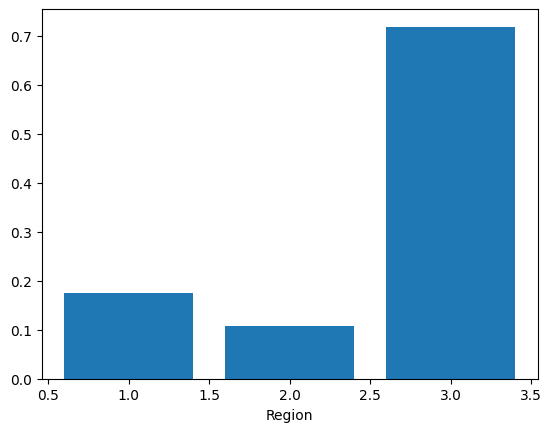

In [1982]:
count = customers["Region"].value_counts(normalize=True)
plt.bar(count.index, count.values)
plt.xlabel("Region")
count

In [1983]:
features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'] 
category_feature = ['Channel', 'Region']

### 3.3 Distribution of Numeric features

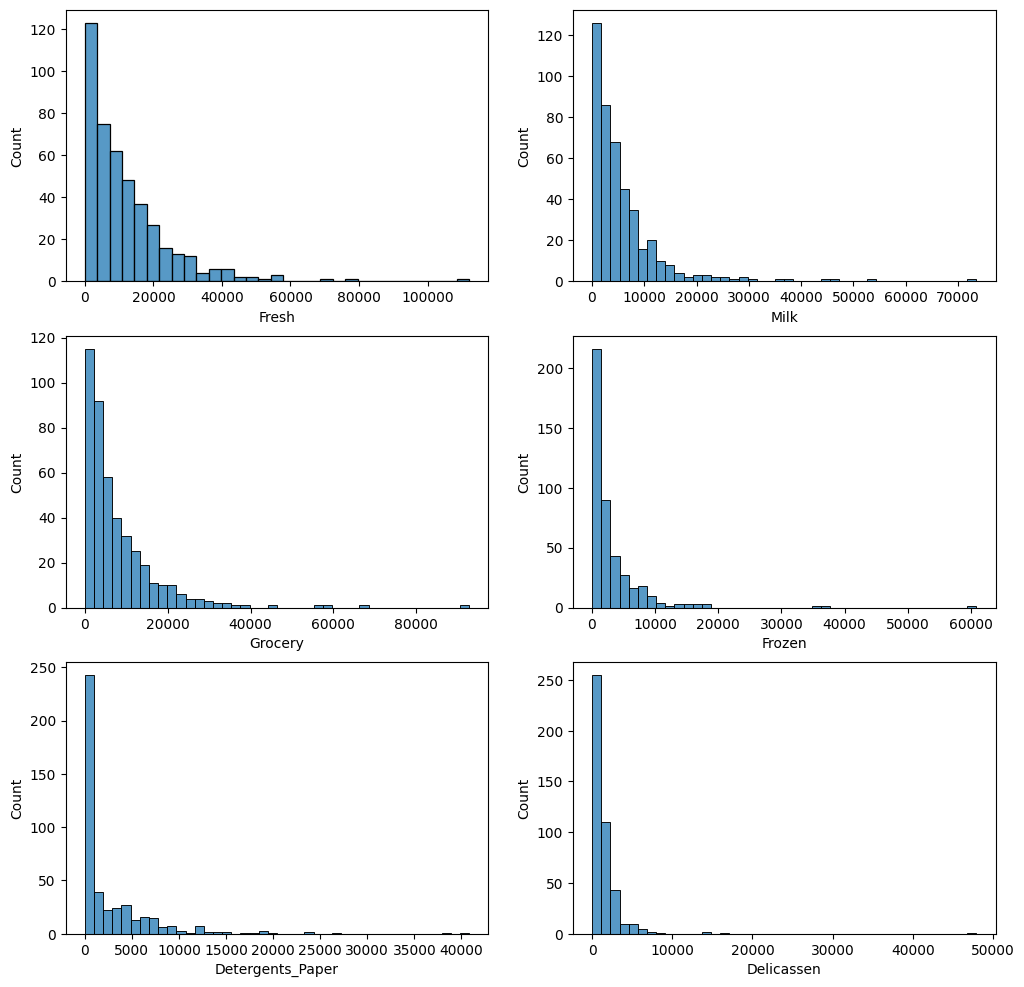

In [1984]:
fig, axes = plt.subplots(3,2, figsize=(12,12))
axes = axes.flatten()
for index, col in enumerate(features):
    sns.histplot(data=customers[col], ax=axes[index])

### 3.4 Check for outliers

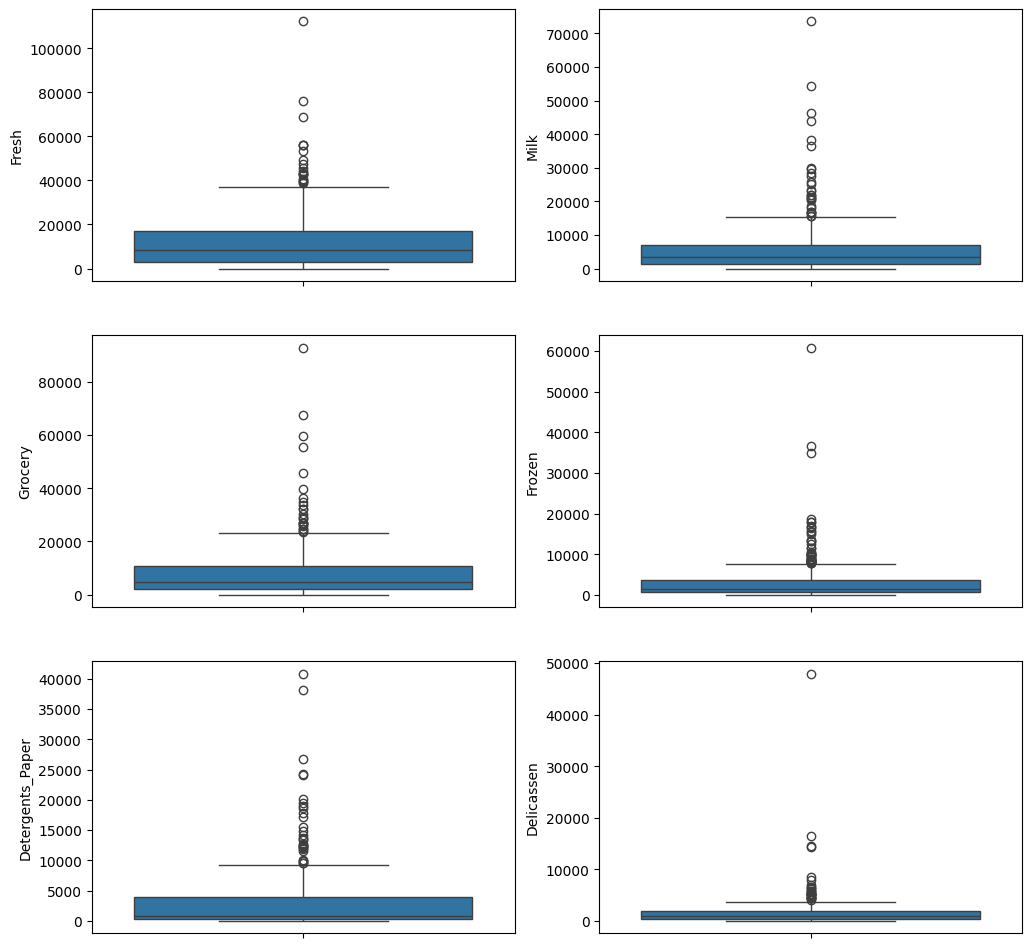

In [1985]:
fig, axes = plt.subplots(3,2, figsize=(12,12))
axes = axes.flatten()
for index, col in enumerate(features):
    sns.boxplot(data=customers[col], ax=axes[index])


EDA Sumamry
- There are no missing value
- There are no duplicate rows
- All the features contains outliers
- consider Channel and Region as categorical features

In [1986]:
# customers.drop(columns=["Channel", "Region"], inplace=True)
# customers.head()

# Execution Plan

First cluster the dataset with raw data(standardized), then cluster after applying log transform(due to the long tail nature of each feature) and standardizing. Will compare the clustering using PCA.

# 4. Clustering with raw data

## 4.1 K-means

###  Preprocessing

In [1987]:
preprocessor = ColumnTransformer(transformers=[
    ('standardscalar', StandardScaler(), features),
    ('onehotencode', OneHotEncoder(handle_unknown='ignore'), category_feature)
])

X_std = preprocessor.fit_transform(customers)

### Find optimal value of K

In [1988]:
K = list(range(2, 20, 1))
wcss_list = []
s_scores = []

for k in K:
    model = KMeans(n_clusters=k, random_state=9)
    model.fit(X_std)
    wcss = model.inertia_
    wcss_list.append(wcss)

    labels = model.predict(X_std) 
    slh_score = silhouette_score(X_std, labels, metric='euclidean')
    s_scores.append(slh_score)

print(wcss_list)
print(s_scores)


[2291.5042104236736, 1945.6167016736306, 1622.8773129355604, 1515.9523145485787, 1242.3151018311112, 1094.4108273099564, 1009.1769268269732, 923.1547387223718, 894.52296235468, 818.0786840728034, 759.6320232950579, 708.3603689640888, 671.0018307590938, 654.8828812041185, 633.0208104484786, 605.5268535979317, 576.8542282445699, 544.6165223226992]
[0.38851313785001984, 0.33215554304745104, 0.3325801735530617, 0.3219268165466917, 0.3296543334542956, 0.2980404668270601, 0.30586540773085447, 0.31006396252870666, 0.29076883035175183, 0.27011407367830775, 0.27377597733635883, 0.27479989726190596, 0.2509970760149834, 0.24802193510971787, 0.2413306330285958, 0.2582598642991407, 0.2583004420751866, 0.2596928177422543]


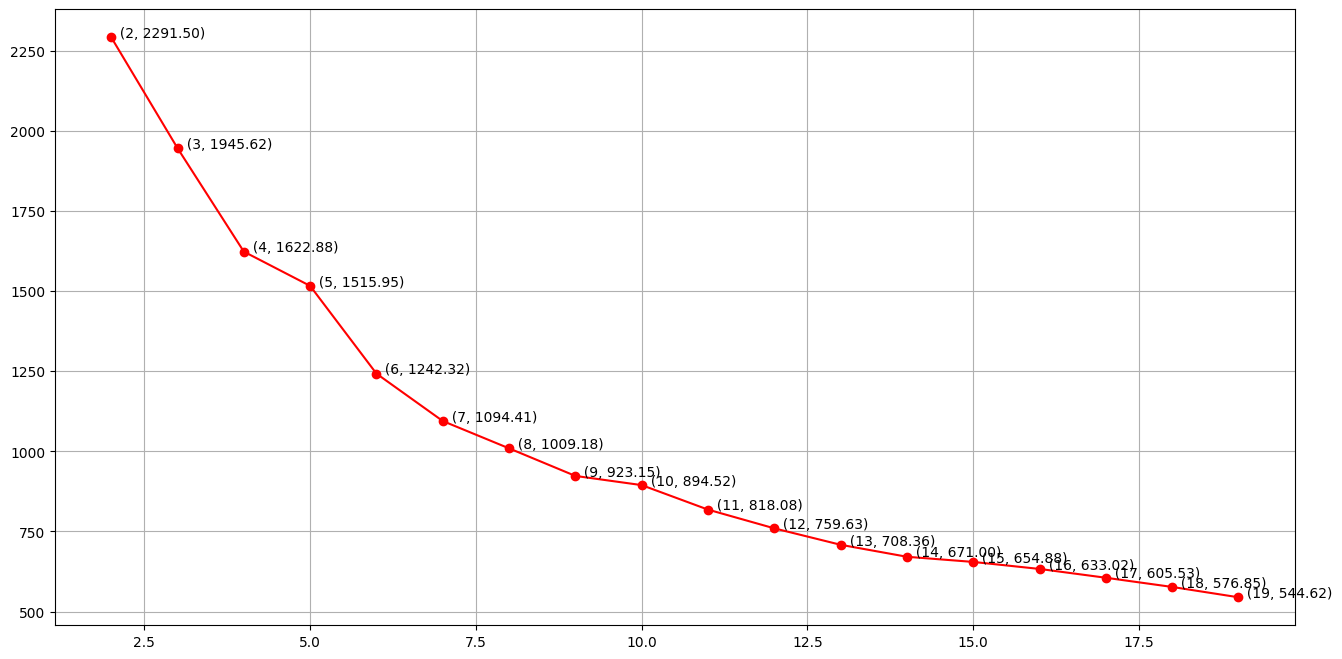

In [1989]:
plt.figure(figsize=(16,8))
plt.plot(K, wcss_list, "ro-")
#plt.plot(K, np.array(s_scores)*10)

for x, y in zip(K, wcss_list):
    plt.text(x, y, f"  ({x}, {y:.2f})")
plt.grid()

In [1990]:
for k in [2, 3, 4, 5, 6, 7, 8, 9]:
    model = KMeans(n_clusters=k, random_state=9)
    model.fit(X_std) 
    labels = model.predict(X_std)

    wcss_kmeans = model.inertia_
    s_score_kmeans = silhouette_score(X_std, labels, metric='euclidean')

    print(k)
    print(f"k-means WCSS: {round(wcss_kmeans,3)}")
    print(f"Silhouette Score: {round(s_score_kmeans,3)}")
    print()

2
k-means WCSS: 2291.504
Silhouette Score: 0.389

3
k-means WCSS: 1945.617
Silhouette Score: 0.332

4
k-means WCSS: 1622.877
Silhouette Score: 0.333

5
k-means WCSS: 1515.952
Silhouette Score: 0.322

6
k-means WCSS: 1242.315
Silhouette Score: 0.33

7
k-means WCSS: 1094.411
Silhouette Score: 0.298

8
k-means WCSS: 1009.177
Silhouette Score: 0.306

9
k-means WCSS: 923.155
Silhouette Score: 0.31



Fit the Kmeans cluster with right k value.
from the above excercise we can safely use k=4 as optimum number of clusters

### Fit the model with optimal K value

In [1991]:
no_of_clusters = 4
model_kmeans = KMeans(n_clusters=no_of_clusters, random_state=9)
labels_kmeans = model_kmeans.fit_predict(X_std)
labels_kmeans

array([3, 3, 3, 1, 0, 3, 3, 3, 1, 3, 3, 1, 3, 3, 3, 1, 3, 1, 3, 1, 1, 1,
       0, 0, 3, 3, 1, 1, 3, 0, 1, 1, 1, 0, 1, 3, 0, 3, 3, 0, 0, 1, 3, 3,
       3, 3, 3, 2, 3, 3, 1, 1, 0, 3, 1, 1, 2, 3, 1, 1, 3, 2, 3, 3, 1, 2,
       1, 3, 1, 1, 1, 0, 1, 1, 3, 1, 1, 3, 1, 1, 1, 3, 3, 1, 3, 2, 2, 0,
       1, 1, 1, 1, 2, 0, 3, 1, 3, 1, 1, 1, 3, 3, 3, 0, 1, 1, 3, 3, 3, 3,
       1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 0, 0, 1, 3, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 3, 3, 1, 3, 3, 3, 1, 1, 3, 3, 3, 3, 1, 1, 1, 3, 3, 1, 3, 1, 3,
       0, 1, 1, 1, 1, 0, 3, 0, 1, 1, 1, 1, 3, 3, 1, 1, 1, 3, 1, 1, 0, 3,
       1, 1, 3, 3, 0, 1, 1, 3, 1, 3, 1, 3, 1, 2, 1, 1, 3, 3, 3, 1, 3, 1,
       1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 3, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       3, 3, 3, 1, 3, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 3, 1, 3, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 3, 1, 1, 1, 3, 3, 1, 3,

In [1992]:
def plot_clusters_counts(labels):    
    value_counts = Counter(labels)

    clusters = list(value_counts.keys())
    counts = list(value_counts.values())

    plt.figure(figsize=(8,4))
    plt.bar(clusters, counts)
    plt.title("Cluster Distribution")
    plt.xlabel("Clusters")
    plt.xticks(list(value_counts.keys()))

    for x, y in zip(clusters, counts):
        plt.text(x=x, y=y, s=str(y))


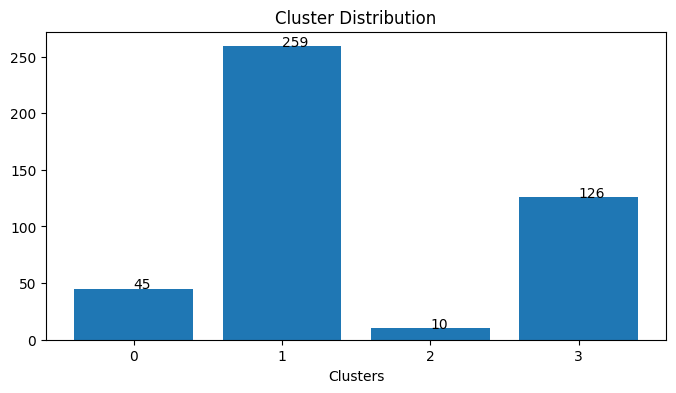

In [1993]:
plot_clusters_counts(labels_kmeans)

In [1994]:
centroids = model_kmeans.cluster_centers_
centroids


array([[ 1.96952628e+00,  1.42379955e-01, -1.28909497e-01,
         1.47203272e+00, -3.96926841e-01,  9.98141016e-01,
         8.88888889e-01,  1.11111111e-01,  1.33333333e-01,
         4.44444444e-02,  8.22222222e-01],
       [-1.69282192e-01, -4.10761370e-01, -4.81063612e-01,
        -8.62510452e-02, -4.55774057e-01, -2.00557935e-01,
         9.72972973e-01,  2.70270270e-02,  2.04633205e-01,
         1.08108108e-01,  6.87258687e-01],
       [ 3.13830315e-01,  3.92190593e+00,  4.27561037e+00,
        -3.57419457e-03,  4.61816580e+00,  5.03365339e-01,
        -1.11022302e-16,  1.00000000e+00,  2.00000000e-01,
         1.00000000e-01,  7.00000000e-01],
       [-3.80340461e-01,  4.82230458e-01,  6.95557930e-01,
        -3.48148489e-01,  7.12107385e-01,  1.58294123e-02,
         4.76190476e-02,  9.52380952e-01,  1.26984127e-01,
         1.26984127e-01,  7.46031746e-01]])

### Sillhouette Score

In [1995]:
silhouette_score_kmeans = silhouette_score(X_std, labels_kmeans, metric='euclidean')
silhouette_score_kmeans

0.3325801735530617

In [1996]:
results =[]

In [1997]:

results.append({
    "Model Name" : "KMeans with standard transformation", 
    "No of Clusters": no_of_clusters,
    "Silhouette Score": silhouette_score_kmeans,
    "Predicted Labels": labels_kmeans
  })

pd.DataFrame(results)


,Model Name,No of Clusters,Silhouette Score,Predicted Labels
0,KMeans with standard transformation,4,0.33258,"[3, 3, 3, 1, 0, 3, 3, 3, 1, 3, 3, 1, 3, 3, 3, ..."


### Cluster visualization with PCA
Check how separable the data is after KMeans clustering

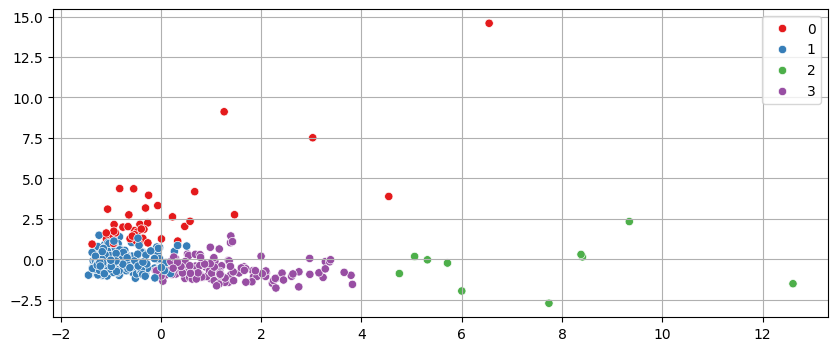

In [1998]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(10,4))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_kmeans, palette="Set1")
plt.grid()

In [1999]:
# customers["Cluster"] = labels_kmeans
# customers.to_csv("clusterd_4.csv")

In [2000]:
# customers_std_df = pd.DataFrame(X_std)
# columns = customers_std_df.columns.to_list()
# customers_std_df[6] = labels_kmeans
# customers_std_df.head()


In [2001]:
# fig, axes = plt.subplots(6,6, figsize=(20,20))

# for col in columns:
#     for col1 in columns:
#         sns.scatterplot(customers_std_df, x=col, y=col1, hue=6, ax=axes[col][col1], palette="Set1")
#         plt.xlabel(col)
#         plt.ylabel(col1)

In [2002]:
#sns.pairplot(customers[features+["Cluster"]], hue="Cluster", palette="Set1")

## 4.2 DBScan

### Preprocessing

In [2003]:
# preprocessor = ColumnTransformer(transformers=[
#     ('standard_scaler', StandardScaler(), features)
# ])

# X_std = preprocessor.fit_transform(customers[features])
#X_std = pca.fit_transform(customers[features])

### find optimal eps and min_poins

In [2004]:
eps_list = np.arange(0.1, 1.0, 0.05) 
min_points = np.arange(5, 40, 5)

eps_list, min_points

(array([0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 ,
        0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95]),
 array([ 5, 10, 15, 20, 25, 30, 35]))

In [2005]:
list(zip(eps_list, min_points))
E, M = np.meshgrid(eps_list, min_points)
eps_minpoints_pairs = list(zip(E.ravel(), M.ravel()))
eps_minpoints_pairs

[(np.float64(0.1), np.int64(5)),
 (np.float64(0.15000000000000002), np.int64(5)),
 (np.float64(0.20000000000000004), np.int64(5)),
 (np.float64(0.25000000000000006), np.int64(5)),
 (np.float64(0.30000000000000004), np.int64(5)),
 (np.float64(0.3500000000000001), np.int64(5)),
 (np.float64(0.40000000000000013), np.int64(5)),
 (np.float64(0.4500000000000001), np.int64(5)),
 (np.float64(0.5000000000000001), np.int64(5)),
 (np.float64(0.5500000000000002), np.int64(5)),
 (np.float64(0.6000000000000002), np.int64(5)),
 (np.float64(0.6500000000000001), np.int64(5)),
 (np.float64(0.7000000000000002), np.int64(5)),
 (np.float64(0.7500000000000002), np.int64(5)),
 (np.float64(0.8000000000000003), np.int64(5)),
 (np.float64(0.8500000000000003), np.int64(5)),
 (np.float64(0.9000000000000002), np.int64(5)),
 (np.float64(0.9500000000000003), np.int64(5)),
 (np.float64(0.1), np.int64(10)),
 (np.float64(0.15000000000000002), np.int64(10)),
 (np.float64(0.20000000000000004), np.int64(10)),
 (np.float64

In [2006]:
def get_optimal_eps_minpoint(values):
    silhouette_scores = []
    out_eps_list = []
    best_score = -1

    for e, m in values:
        dbscan = DBSCAN(eps=e, min_samples=m, metric='euclidean')
        #dbscan.fit(X_std)

        labels = dbscan.fit_predict(X_std)
        unique_labels = set(labels)
        #print(len(unique_labels))
        if len(unique_labels) > 2:

            score = silhouette_score(X_std, labels, metric='euclidean')
            if score > best_score:
                best_score = score
                best_eps = e
                best_min_points = m
                best_unique_lebels = unique_labels

            silhouette_scores.append(score)
            out_eps_list.append(e)
        else:
            silhouette_scores.append(-1)
            out_eps_list.append(e)

    print(silhouette_scores)

    return best_score, best_eps, best_min_points, best_unique_lebels
    

In [2007]:
best_score, best_eps, best_min_points, unique_labels = get_optimal_eps_minpoint(eps_minpoints_pairs)
print(f"Best Silhouette score: {best_score}, best eps: {best_eps}, best min points: {best_min_points}, unique labels: {unique_labels}")

[-1, -1, -0.29556313577559257, -0.2433556953092007, -1, -0.16087879772465194, -0.052680056430244884, -0.13443854627416482, -0.11097344680696837, -0.055216125042541496, -0.0087325528219579, 0.03396962809571743, 0.12595703206391437, 0.1407381121861994, 0.1621922535543976, 0.1809900935214274, 0.18271362223177398, 0.1858766119528844, -1, -1, -1, -1, -1, -1, -0.16361880728608827, -1, -0.035547430792032, -0.007771004772160041, -0.08323032466072579, -0.006028368484408581, 0.05891639633644893, 0.08120238039951914, 0.12472161290556669, 0.1464416926699014, 0.1658302708531247, 0.1678083007030761, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 0.008641800704275901, -0.030595068786669243, -0.005095790365027126, 0.05946560355090751, 0.1147497259008521, 0.13031350467004033, 0.14947461491892564, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 0.014453818896219401, -0.018353496687410847, 0.05455341966957909, 0.08521476244208334, 0.11139659132358033, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 

### fit the model

In [2008]:
final_dbscan = DBSCAN(eps = best_eps, min_samples=best_min_points)
final_labels_dbscan = final_dbscan.fit_predict(X_std)


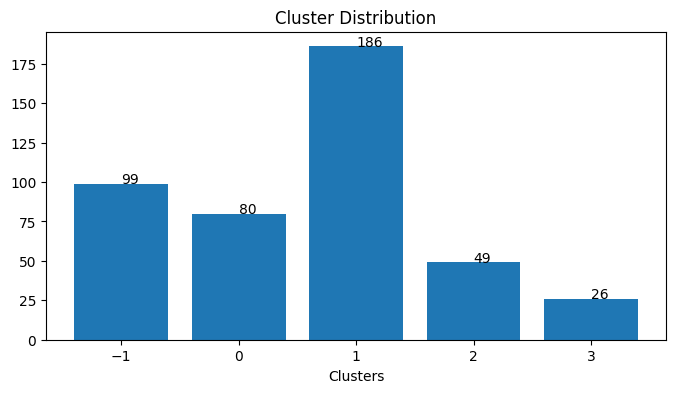

In [2009]:
plot_clusters_counts(final_labels_dbscan)

### Silhouette score

In [2010]:
silhouette_score_dbscan = silhouette_score(X_std, final_labels_dbscan, metric='euclidean')
silhouette_score_dbscan

0.1858766119528844

In [2011]:
no_of_clusters_dbscan = len(list(Counter(final_labels_dbscan).values()))
results.append({
    "Model Name" : "DBScan with standard transformation", 
    "No of Clusters": no_of_clusters_dbscan,
    "Silhouette Score": silhouette_score_dbscan,
    "Predicted Labels": final_labels_dbscan
  })

pd.DataFrame(results)

,Model Name,No of Clusters,Silhouette Score,Predicted Labels
0,KMeans with standard transformation,4,0.332580,"[3, 3, 3, 1, 0, 3, 3, 3, 1, 3, 3, 1, 3, 3, 3, ..."
1,DBScan with standard transformation,5,0.185877,"[0, 0, -1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,..."


### Cluster visualization with PCA

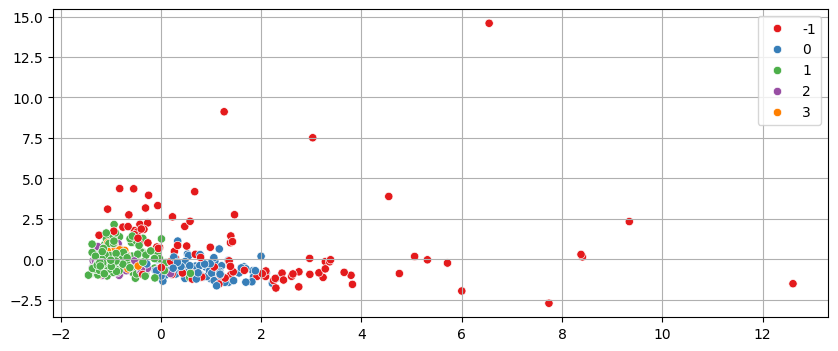

In [2012]:
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(10,4))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=final_labels_dbscan, palette="Set1")
plt.grid()

## 4.4 Agglomerative

### Preprocessing

In [2013]:
# preprocessor = ColumnTransformer(transformers=[
#     ('standardscaler', StandardScaler(), features)
# ])

# X_std = preprocessor.fit_transform(customers[features])

### Fit the model

In [2014]:
model_agg = AgglomerativeClustering(n_clusters=no_of_clusters, linkage='ward')
labels_agg = model_agg.fit_predict(X_std)

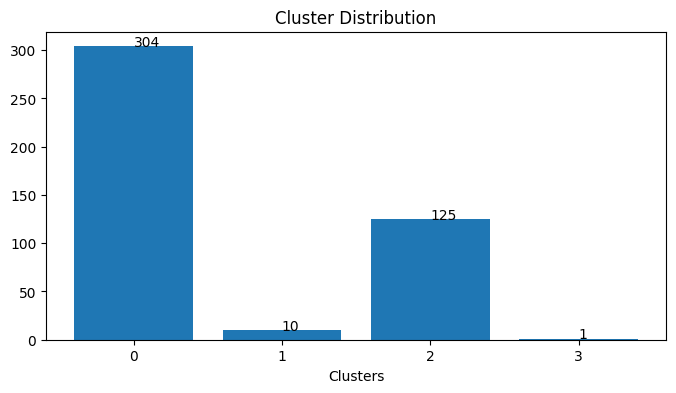

In [2015]:
plot_clusters_counts(labels_agg)

### Silhouette Score

In [2016]:
silhouette_score_agg = silhouette_score(X_std, labels_agg, metric='euclidean')
silhouette_score_agg

0.3089856174922482

In [2017]:

results.append({
    "Model Name" : "AgglomerativeClustering with standard transformation", 
    "No of Clusters": no_of_clusters,
    "Silhouette Score": silhouette_score_agg,
    "Predicted Labels": labels_agg
  })

pd.DataFrame(results)

,Model Name,No of Clusters,Silhouette Score,Predicted Labels
0,KMeans with standard transformation,4,0.332580,"[3, 3, 3, 1, 0, 3, 3, 3, 1, 3, 3, 1, 3, 3, 3, ..."
1,DBScan with standard transformation,5,0.185877,"[0, 0, -1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,..."
2,AgglomerativeClustering with standard transfor...,4,0.308986,"[2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, ..."


### Visualize the clustering with PCA

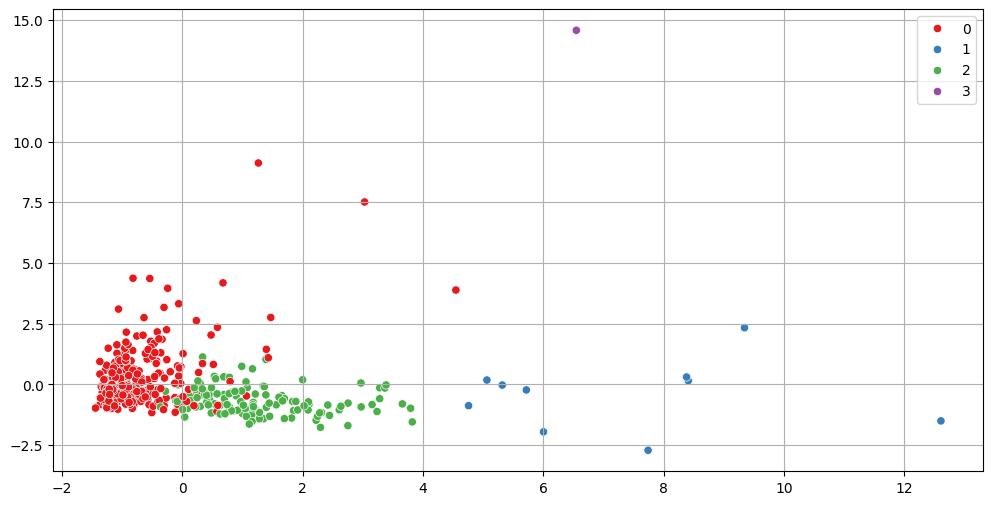

In [2018]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(12,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_agg, palette="Set1")
plt.grid()

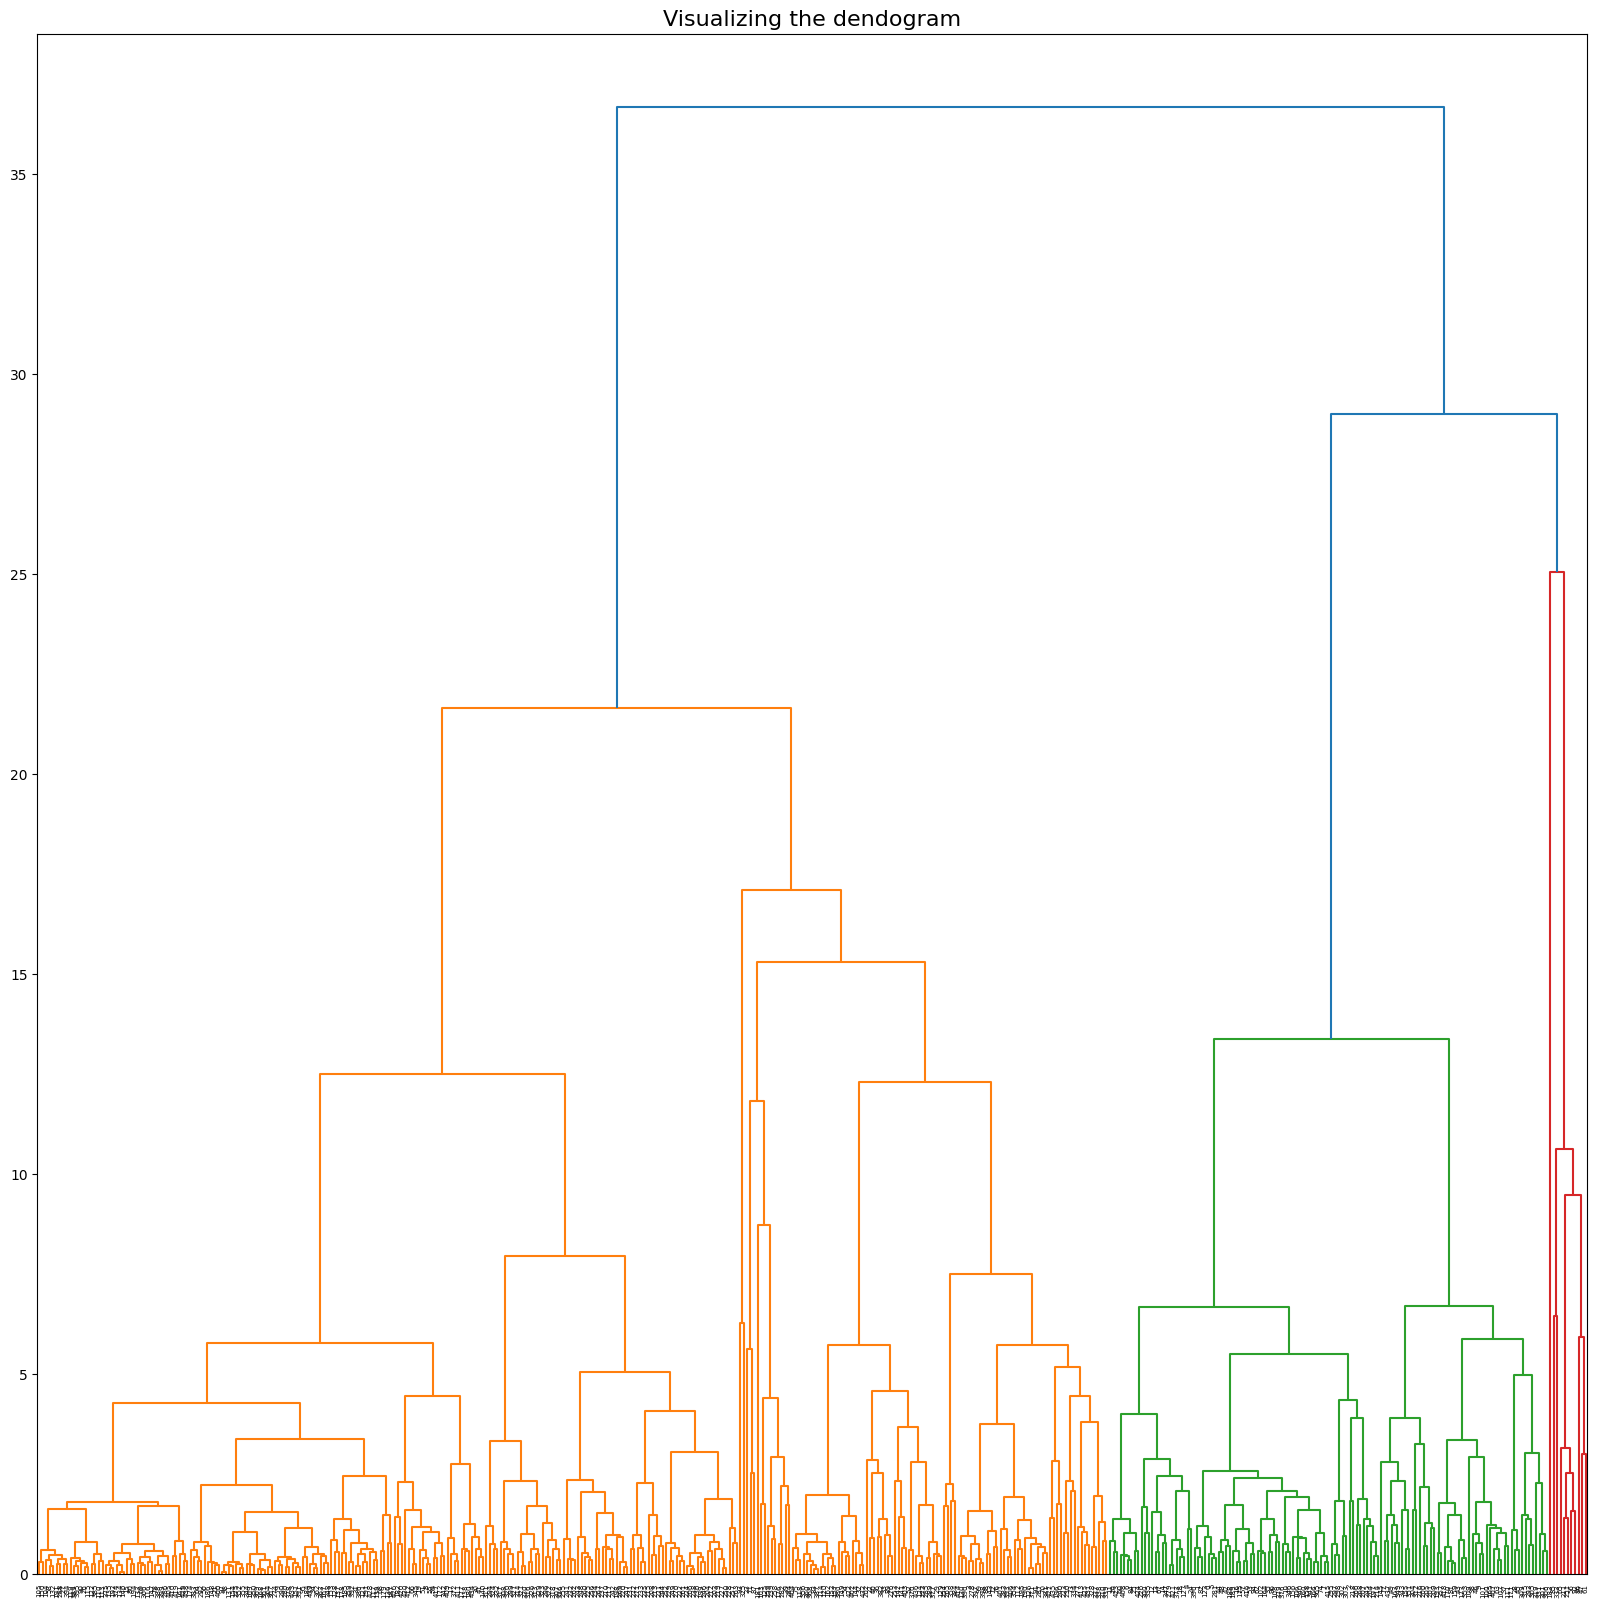

In [2019]:
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(20,20))
Dendogram = shc.dendrogram((shc.linkage(X_std, method='ward')))
plt.title("Visualizing the dendogram", size=16)
plt.show()

# 5. Clustering with log transformed data data

## 5.1 KMeans

### PreProcessing

In [2020]:
transform_pipeline = Pipeline(steps=[
     ('log', FunctionTransformer(np.log1p, validate=True)),
     ('standard', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('log-standard', transform_pipeline, features),
    ('onehotencode', OneHotEncoder(handle_unknown='ignore'), category_feature)
])
X_std = preprocessor.fit_transform(customers)


In [2021]:
for k in [2, 3, 4, 5, 6, 7, 8, 9]:
    model = KMeans(n_clusters=k, random_state=9)
    model.fit(X_std) 
    labels = model.predict(X_std)

    wcss_kmeans = model.inertia_
    s_score_kmeans = silhouette_score(X_std, labels, metric='euclidean')

    print(k)
    print(f"k-means WCSS: {round(wcss_kmeans,3)}")
    print(f"Silhouette Score: {round(s_score_kmeans,3)}")
    print()

2
k-means WCSS: 2117.244
Silhouette Score: 0.291

3
k-means WCSS: 1842.584
Silhouette Score: 0.191

4
k-means WCSS: 1717.928
Silhouette Score: 0.175

5
k-means WCSS: 1590.785
Silhouette Score: 0.161

6
k-means WCSS: 1421.991
Silhouette Score: 0.171

7
k-means WCSS: 1338.909
Silhouette Score: 0.173

8
k-means WCSS: 1271.875
Silhouette Score: 0.169

9
k-means WCSS: 1236.708
Silhouette Score: 0.155



### Fit the model

In [2022]:
model_kmeans_log = KMeans(n_clusters=no_of_clusters, random_state=9)
labels_kmeans_log = model_kmeans_log.fit_predict(X_std)
labels_kmeans_log

array([3, 3, 0, 2, 0, 3, 3, 3, 2, 3, 3, 2, 3, 3, 3, 2, 3, 2, 0, 2, 0, 2,
       0, 0, 0, 3, 2, 2, 3, 2, 0, 2, 2, 0, 2, 3, 0, 3, 3, 2, 0, 0, 3, 3,
       3, 3, 3, 0, 3, 3, 2, 3, 3, 3, 2, 2, 3, 3, 2, 3, 3, 3, 0, 3, 2, 3,
       3, 3, 0, 2, 2, 0, 2, 0, 3, 1, 2, 3, 1, 2, 2, 3, 3, 2, 3, 3, 3, 0,
       1, 0, 1, 2, 3, 0, 3, 3, 3, 1, 1, 2, 0, 3, 3, 0, 2, 2, 3, 3, 3, 3,
       2, 3, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 3, 2, 0, 2, 3, 1, 2, 2, 1,
       2, 1, 2, 2, 0, 3, 2, 2, 0, 2, 1, 2, 2, 3, 2, 2, 1, 2, 2, 2, 2, 2,
       1, 3, 3, 2, 3, 3, 3, 1, 2, 3, 3, 0, 3, 2, 1, 1, 3, 3, 3, 3, 2, 3,
       0, 2, 2, 2, 0, 0, 3, 0, 1, 2, 1, 3, 3, 3, 2, 1, 2, 3, 2, 0, 0, 3,
       2, 2, 3, 3, 0, 1, 1, 3, 1, 3, 3, 3, 2, 3, 2, 3, 3, 3, 3, 2, 3, 1,
       1, 3, 2, 0, 1, 2, 0, 2, 1, 2, 0, 2, 2, 1, 2, 2, 2, 2, 1, 0, 0, 2,
       2, 2, 0, 3, 2, 1, 2, 2, 2, 3, 2, 0, 0, 1, 2, 2, 0, 0, 2, 1, 2, 2,
       3, 0, 3, 2, 3, 1, 1, 2, 2, 2, 2, 1, 0, 1, 2, 3, 2, 3, 0, 0, 0, 1,
       2, 2, 1, 1, 2, 2, 2, 3, 2, 3, 2, 3, 3, 1, 3,

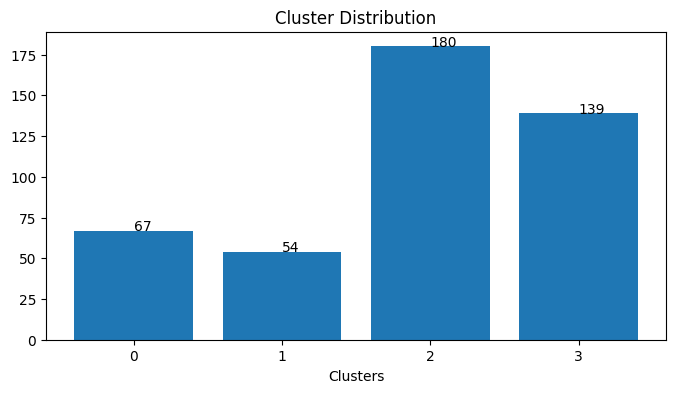

In [2023]:
plot_clusters_counts(labels_kmeans_log)

### Silhouette score

In [2024]:
silhouette_score_kmeans = silhouette_score(X_std, labels_kmeans_log, metric='euclidean')
silhouette_score_kmeans

0.1747595162979467

In [2025]:

results.append({
    "Model Name" : "KMeans with log+standard transformation", 
    "No of Clusters": no_of_clusters,
    "Silhouette Score": silhouette_score_kmeans,
    "Predicted Labels": labels_kmeans_log
  })

pd.DataFrame(results)

,Model Name,No of Clusters,Silhouette Score,Predicted Labels
0,KMeans with standard transformation,4,0.332580,"[3, 3, 3, 1, 0, 3, 3, 3, 1, 3, 3, 1, 3, 3, 3, ..."
1,DBScan with standard transformation,5,0.185877,"[0, 0, -1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,..."
2,AgglomerativeClustering with standard transfor...,4,0.308986,"[2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, ..."
3,KMeans with log+standard transformation,4,0.174760,"[3, 3, 0, 2, 0, 3, 3, 3, 2, 3, 3, 2, 3, 3, 3, ..."


### Cluster visualization with PCA

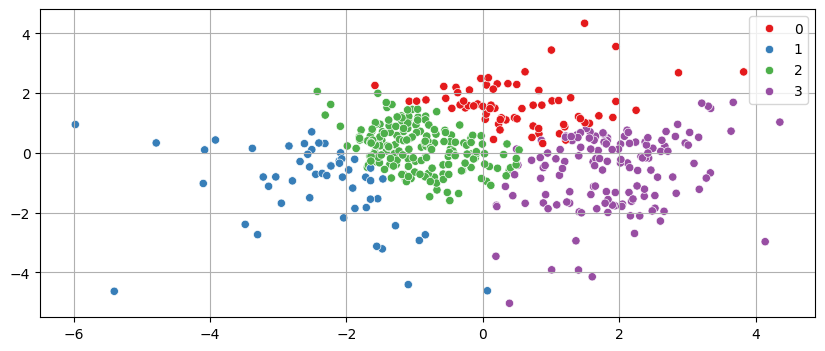

In [2026]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(10,4))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_kmeans_log, palette="Set1")
plt.grid()

## 5.3 Agglomerative

### Preprocessing

In [2027]:
# transform_pipeline = Pipeline(steps=[
#      ('log', FunctionTransformer(np.log1p, validate=True)),
#      ('standard', StandardScaler())
# ])

# preprocessor = ColumnTransformer(transformers=[
#     ('log-standard', transform_pipeline, features)
# ])
# X_std = preprocessor.fit_transform(customers[features])

### fit the model

In [2028]:
model_agg = AgglomerativeClustering(n_clusters=no_of_clusters, linkage='ward')
labels_agg_log = model_agg.fit_predict(X_std)
silhouette_score_agg = silhouette_score(X_std, labels_agg_log, metric='euclidean')
silhouette_score_agg

0.18784050663243193

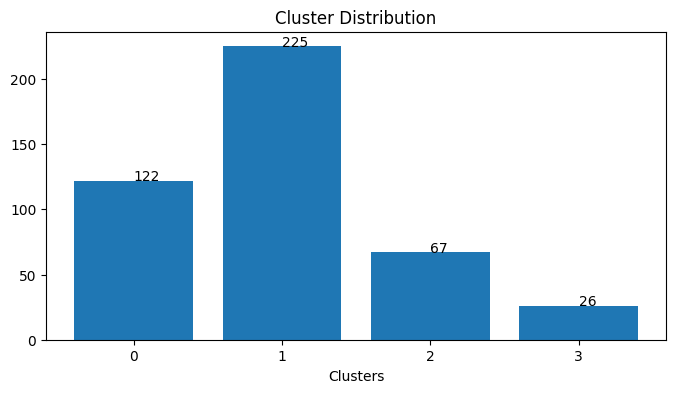

In [2029]:
plot_clusters_counts(labels_agg_log)

In [2030]:

results.append({
    "Model Name" : "AgglomerativeClustering with log+standard transformation", 
    "No of Clusters": no_of_clusters,
    "Silhouette Score": silhouette_score_agg,
    "Predicted Labels": labels_agg_log
  })

pd.DataFrame(results)

,Model Name,No of Clusters,Silhouette Score,Predicted Labels
0,KMeans with standard transformation,4,0.332580,"[3, 3, 3, 1, 0, 3, 3, 3, 1, 3, 3, 1, 3, 3, 3, ..."
1,DBScan with standard transformation,5,0.185877,"[0, 0, -1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,..."
2,AgglomerativeClustering with standard transfor...,4,0.308986,"[2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, ..."
3,KMeans with log+standard transformation,4,0.174760,"[3, 3, 0, 2, 0, 3, 3, 3, 2, 3, 3, 2, 3, 3, 3, ..."
4,AgglomerativeClustering with log+standard tran...,4,0.187841,"[0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."


### Visualize the clustering with PCA

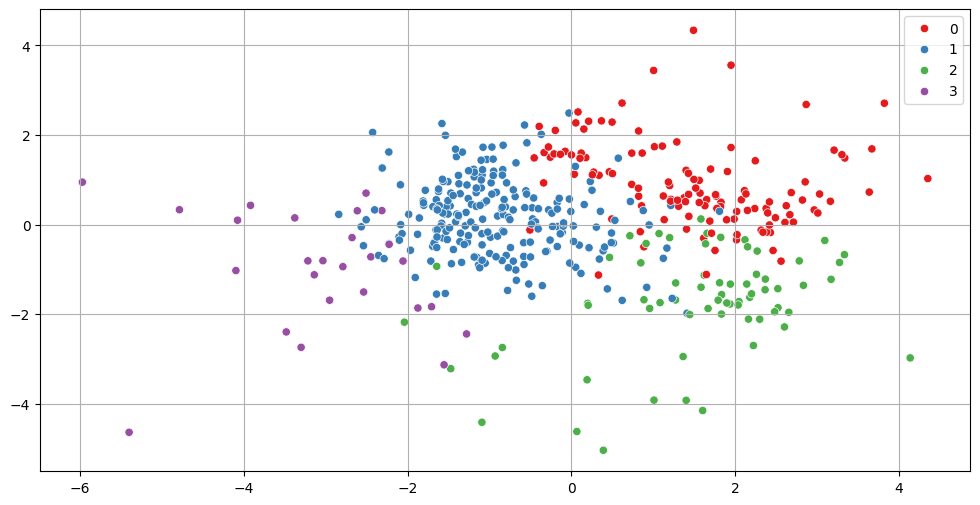

In [2031]:
plt.figure(figsize=(12,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_agg_log, palette="Set1")
plt.grid()

# 6. Clustering without Outliers

In [2032]:
customers = pd.read_csv("Wholesale_customers_data.csv")

In [2033]:
customers.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [2034]:
features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'] 
category_feature = ['Channel', 'Region']


In [2035]:
customers.duplicated().sum()

np.int64(0)

In [2036]:
outliers = []
customer_no_outlier = customers.copy()

### Remove extreme outliers

In [2037]:
outlier_indices = set()
outliers = []

for col in features:

    #print(f"processing {col} feature")
    q1, q2, q3 = np.quantile(customer_no_outlier[col], [0.25, 0.5, 0.75])
    iqr = q3 - q1
    lower = customer_no_outlier[col].quantile(0.01) #q1 - 2 * iqr
    upper = customer_no_outlier[col].quantile(0.99) #q3 + 2 * iqr

    outlier_count = customer_no_outlier[customer_no_outlier[col] > upper].shape[0] + customer_no_outlier[customer_no_outlier[col] < lower].shape[0]
    #print(customers[customers[col] > upper])

    outliers.append({"Feature": col, "Number_of_Outliers": outlier_count})

    indices = np.where((customer_no_outlier[col] > upper) | (customer_no_outlier[col] < lower))[0]
    #print(customers.iloc[indices, :])
    outlier_indices.update(indices)

   
print(pd.DataFrame(outliers).sort_values(by="Number_of_Outliers", ascending=False))
print(f"Row index to be removed: {list(outlier_indices)}")
print(f"Total Count: {len(outlier_indices)}")  
customer_no_outlier = customer_no_outlier.drop(list(outlier_indices))


print(f"Shape of dataset before outlier removal: {customers.shape}")
print(f"Shape of DataSet after outlier removal: {customer_no_outlier.shape}")

            Feature  Number_of_Outliers
0             Fresh                  10
1              Milk                  10
2           Grocery                  10
3            Frozen                  10
4  Detergents_Paper                  10
5        Delicassen                  10
Row index to be removed: [np.int64(128), np.int64(258), np.int64(142), np.int64(145), np.int64(275), np.int64(23), np.int64(154), np.int64(284), np.int64(161), np.int64(420), np.int64(38), np.int64(39), np.int64(47), np.int64(181), np.int64(183), np.int64(57), np.int64(187), np.int64(61), np.int64(65), np.int64(66), np.int64(196), np.int64(325), np.int64(71), np.int64(75), np.int64(204), np.int64(333), np.int64(338), np.int64(85), np.int64(86), np.int64(87), np.int64(218), np.int64(93), np.int64(95), np.int64(96), np.int64(97), np.int64(98), np.int64(356), np.int64(103), np.int64(233), np.int64(109), np.int64(122), np.int64(125)]
Total Count: 42
Shape of dataset before outlier removal: (440, 8)
Shape of DataSet

In [2038]:
customer_no_outlier.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## 6.1 KMeans

### preprocessing

In [2039]:
transform_pipeline = Pipeline(steps=[
     ('boxcox', PowerTransformer(method='box-cox')),  #FunctionTransformer(np.log1p, validate=True)),
     ('standard', StandardScaler())
])

preprocessor_boxcox = ColumnTransformer(transformers=[
    ('boxcox-standard', transform_pipeline, features),
    ('onehotencode', OneHotEncoder(handle_unknown='ignore'), category_feature)
])
preprocessor_boxcox


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('boxcox-standard', ...), ('onehotencode', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``f

In [2040]:
#X_std = preprocessor.fit_transform(customer_no_outlier[features])
X_std = preprocessor_boxcox.fit_transform(customer_no_outlier)
X_std

array([[ 0.47264848,  1.10347347,  0.52026326, ...,  0.        ,
         0.        ,  1.        ],
       [-0.11748364,  1.12072276,  0.76519642, ...,  0.        ,
         0.        ,  1.        ],
       [-0.21249198,  1.00356521,  0.53704083, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 0.62729157,  1.62511119,  1.96761998, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.250405  , -0.54917086, -0.74351457, ...,  0.        ,
         0.        ,  1.        ],
       [-0.85834026, -0.70241444, -0.62233724, ...,  0.        ,
         0.        ,  1.        ]], shape=(398, 11))

### visualize the data after transformation

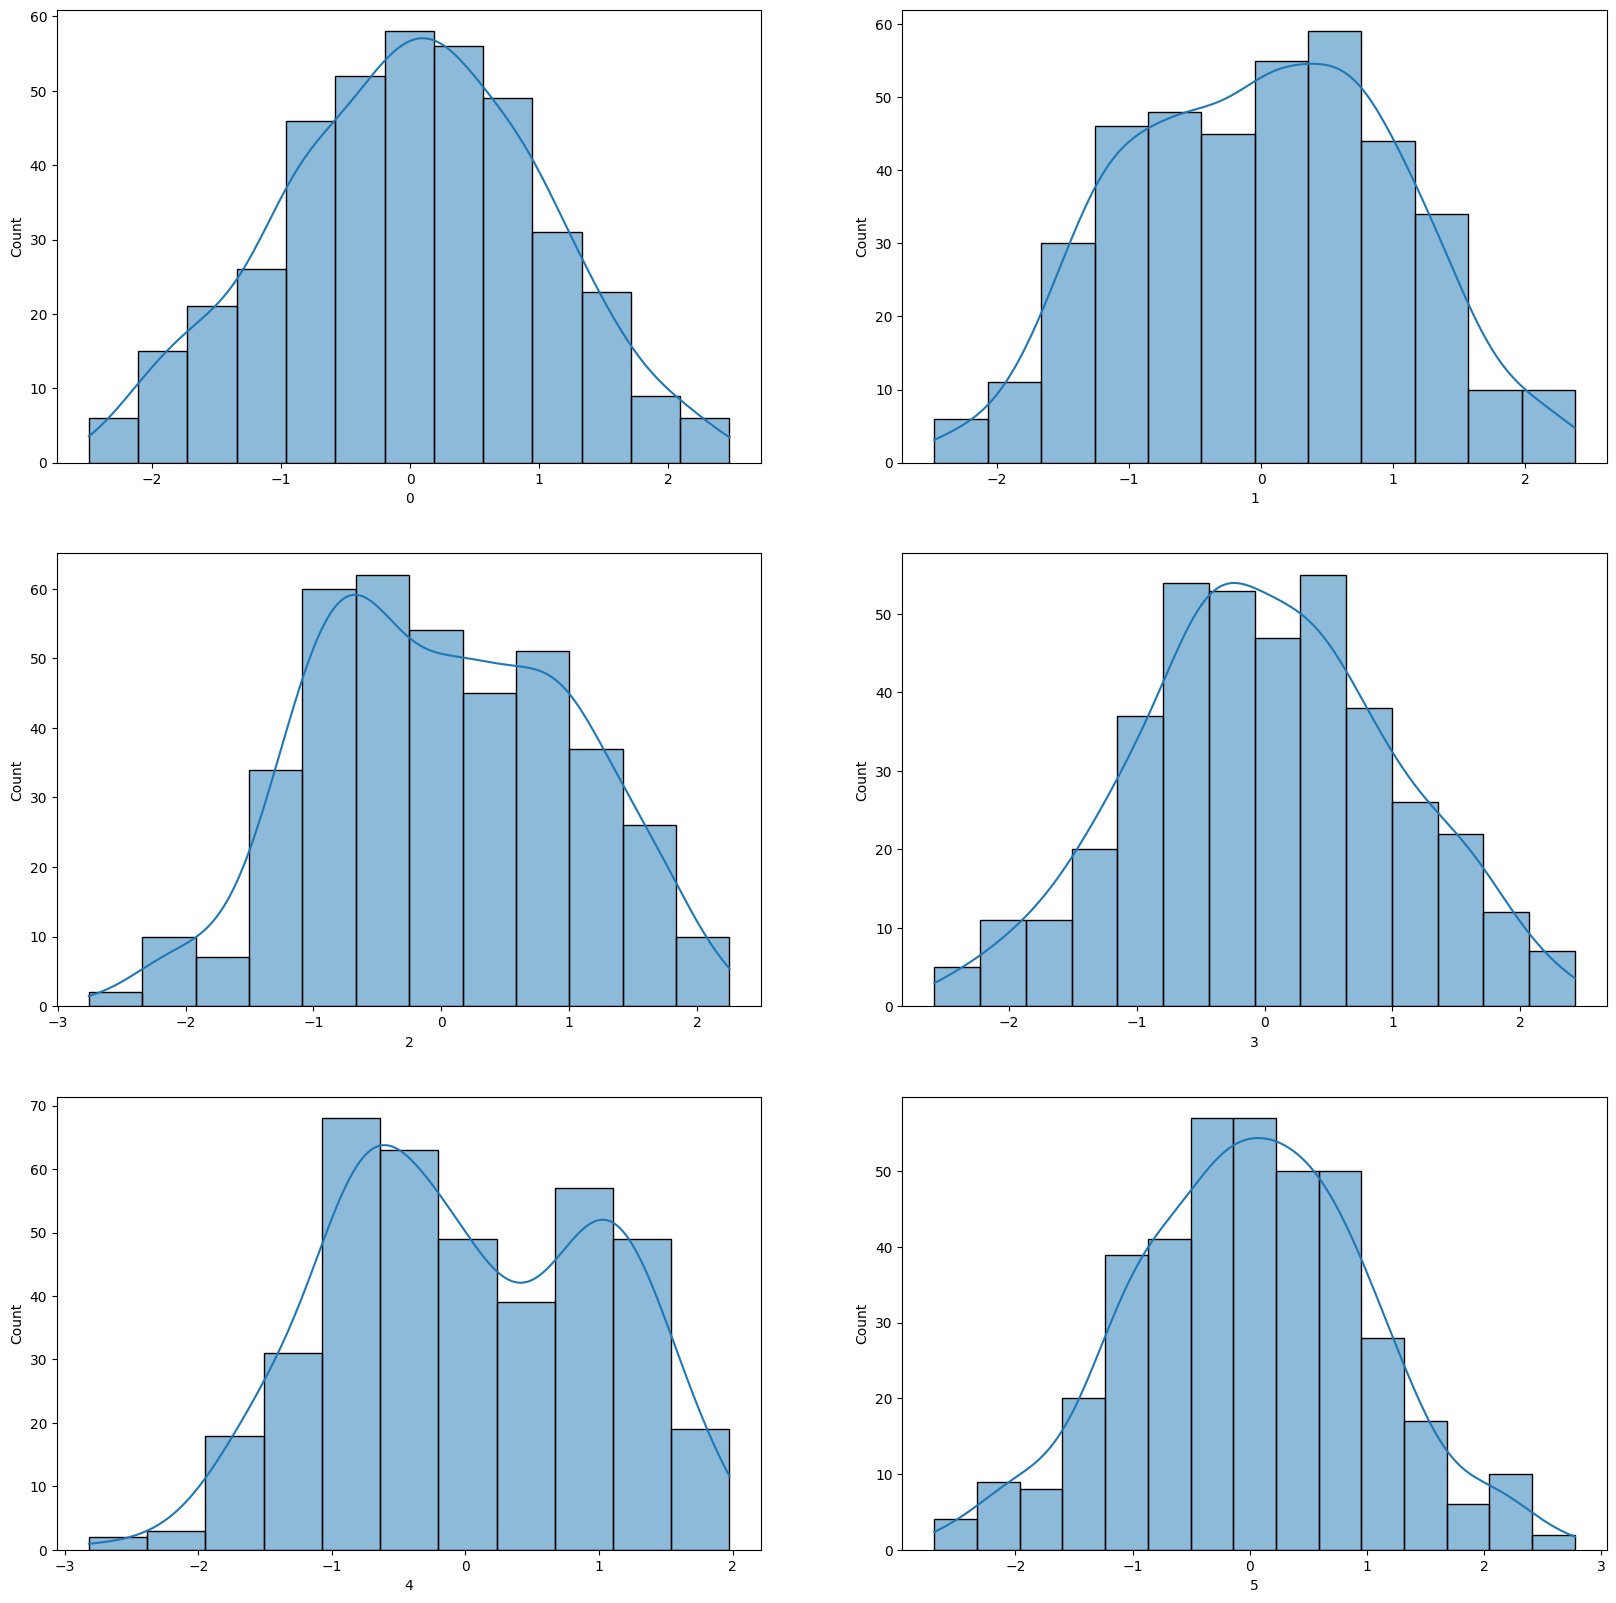

In [2041]:

customers_std_df = pd.DataFrame(X_std[:, :6])
fig, axes = plt.subplots(3,2, figsize=(20,20))
axes = axes.flatten()

for col in customers_std_df.columns.to_list():
    #sns.histplot(data=customers, x=col, ax=axes[col], kde=True)
    sns.histplot(data=customers_std_df, x=col, ax=axes[col], kde=True)
    plt.xlabel(col)
  

### find optimal value of K

In [2042]:
K = list(range(2, 20, 1))
wcss_list = []
s_scores = []

for k in K:
    model = KMeans(n_clusters=k, random_state=9)
    model.fit(X_std)
    wcss = model.inertia_
    wcss_list.append(wcss)

    labels = model.predict(X_std) 
    slh_score = silhouette_score(X_std, labels, metric='euclidean')
    s_scores.append(slh_score)

print(wcss_list)
print(s_scores)


[1839.7125642584515, 1588.4261102002056, 1444.5458402064576, 1336.227753945844, 1276.9950687033208, 1216.1236174212231, 1130.0232421033375, 1094.344978177575, 1058.3441139731124, 1024.01837794414, 995.4989254998565, 954.5715604986469, 931.6960510718632, 910.7721904747254, 883.142916195394, 859.4160164808179, 831.8880892587636, 824.3378652563606]
[0.2985149873661212, 0.2202031263649239, 0.17016927901912676, 0.1573304061920126, 0.1422073687370715, 0.13723487388636604, 0.14700178578550452, 0.14221412292060961, 0.14061379937975824, 0.14146937208392515, 0.13937218132189372, 0.14217428613861222, 0.14142694585704021, 0.1417574194614899, 0.14188261452621034, 0.14534954645179263, 0.14549138494119757, 0.1386602702960497]


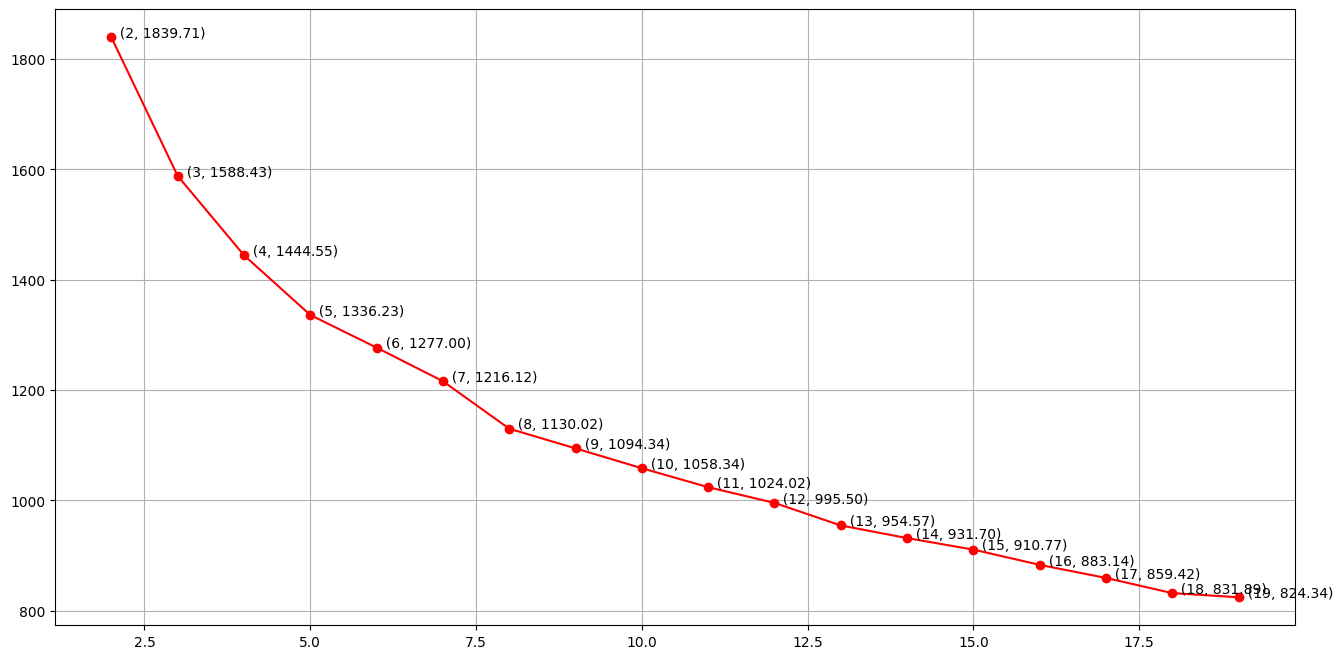

In [2043]:
plt.figure(figsize=(16,8))
plt.plot(K, wcss_list, "ro-")
#plt.plot(K, np.array(s_scores)*10)

for x, y in zip(K, wcss_list):
    plt.text(x, y, f"  ({x}, {y:.2f})")
plt.grid()

In [2044]:
### fit the model

In [2045]:
no_of_clusters = 4
model_kmeans_no_outliers = KMeans(n_clusters=no_of_clusters, random_state=9)
model_kmeans_no_outliers.fit(X_std)
labels_kmeans_wo_outlier = model_kmeans_no_outliers.predict(X_std)

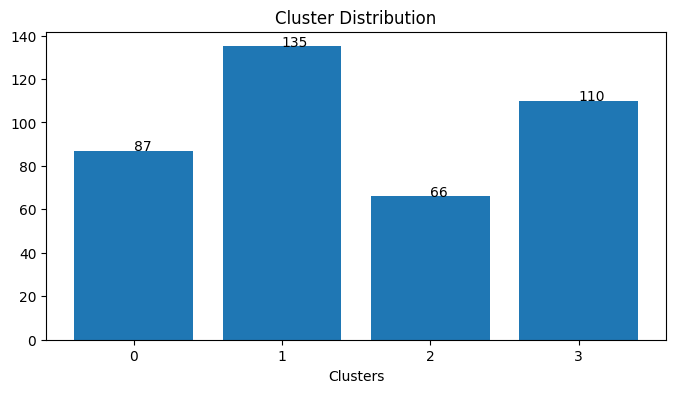

In [2046]:
plot_clusters_counts(labels_kmeans_wo_outlier)


### silhouette score

In [2047]:
silhouette_score_kmeans_wo_outliers = silhouette_score(X_std, labels_kmeans_wo_outlier, metric='euclidean')
silhouette_score_kmeans_wo_outliers

0.17016927901912676

In [2048]:

results.append({
    "Model Name" : "KMeans without outliers", 
    "No of Clusters": no_of_clusters,
    "Silhouette Score": silhouette_score_kmeans_wo_outliers,
    "Predicted Labels": labels_kmeans_wo_outlier
  })

results_df = pd.DataFrame(results)
results_df

,Model Name,No of Clusters,Silhouette Score,Predicted Labels
0,KMeans with standard transformation,4,0.332580,"[3, 3, 3, 1, 0, 3, 3, 3, 1, 3, 3, 1, 3, 3, 3, ..."
1,DBScan with standard transformation,5,0.185877,"[0, 0, -1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,..."
2,AgglomerativeClustering with standard transfor...,4,0.308986,"[2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, ..."
3,KMeans with log+standard transformation,4,0.174760,"[3, 3, 0, 2, 0, 3, 3, 3, 2, 3, 3, 2, 3, 3, 3, ..."
4,AgglomerativeClustering with log+standard tran...,4,0.187841,"[0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
5,KMeans without outliers,4,0.170169,"[0, 0, 0, 3, 0, 0, 2, 0, 2, 0, 0, 1, 0, 0, 0, ..."


### Visialize the cluster with PCA

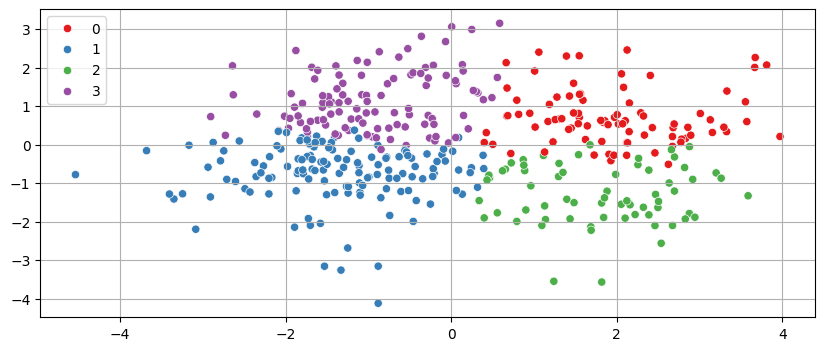

In [2049]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(10,4))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_kmeans_wo_outlier, palette="Set1")
plt.grid()

## 6.2 Agglomerative

In [2050]:
model_agg = AgglomerativeClustering(n_clusters=no_of_clusters, linkage='ward')
labels_agg_log = model_agg.fit_predict(X_std)
silhouette_score_agg_wo_outliers = silhouette_score(X_std, labels_agg_log, metric='euclidean')
silhouette_score_agg_wo_outliers

0.16040975372502017

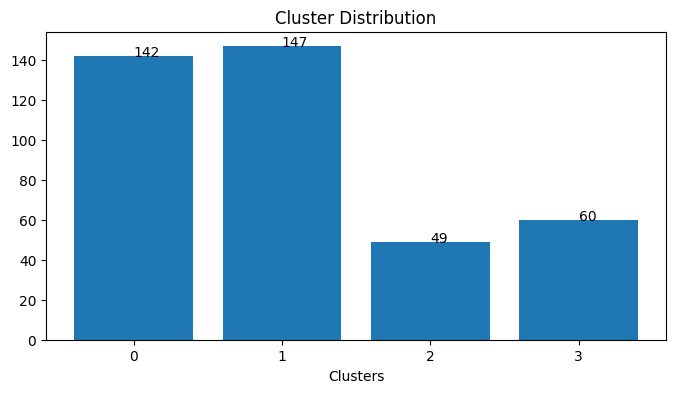

In [2051]:
plot_clusters_counts(labels_agg_log)

In [2052]:

results.append({
    "Model Name" : "Agglomerative without outliers", 
    "No of Clusters": no_of_clusters,
    "Silhouette Score": silhouette_score_agg_wo_outliers,
    "Predicted Labels": labels_agg_log
  })

results_df = pd.DataFrame(results)
results_df

,Model Name,No of Clusters,Silhouette Score,Predicted Labels
0,KMeans with standard transformation,4,0.332580,"[3, 3, 3, 1, 0, 3, 3, 3, 1, 3, 3, 1, 3, 3, 3, ..."
1,DBScan with standard transformation,5,0.185877,"[0, 0, -1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,..."
2,AgglomerativeClustering with standard transfor...,4,0.308986,"[2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, ..."
3,KMeans with log+standard transformation,4,0.174760,"[3, 3, 0, 2, 0, 3, 3, 3, 2, 3, 3, 2, 3, 3, 3, ..."
4,AgglomerativeClustering with log+standard tran...,4,0.187841,"[0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
5,KMeans without outliers,4,0.170169,"[0, 0, 0, 3, 0, 0, 2, 0, 2, 0, 0, 1, 0, 0, 0, ..."
6,Agglomerative without outliers,4,0.160410,"[0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


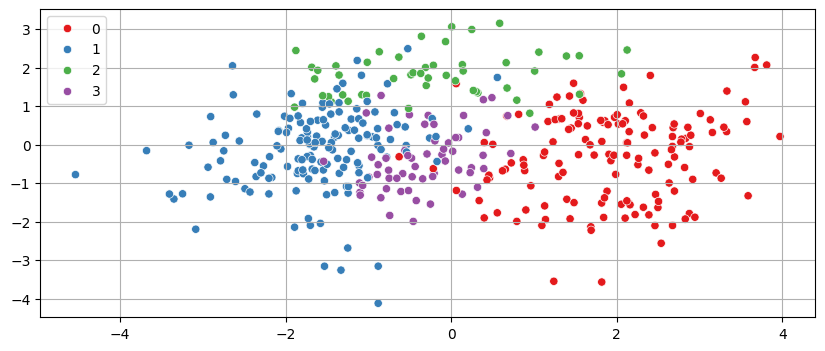

In [2053]:
# pca = PCA(n_components=2, random_state=9)
# X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(10,4))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_agg_log, palette="Set1")
plt.grid()

# Summary

1. Got Best Silhouette Score when the data is transformed with StandardScalar and modeled with Kmeans - 0.3325
2. This wholesale dataset is highly overlapping, so DBScan is not performing well with this dataset.
3. Clusters generated from each model are visualized with PCA with 2 components. Though Silhouette score of the model is low after removing outliers but it is observed from PCA scatterplot that the clusters are better separated. 
4. After careful consideration, it is decided to use the KMeans model created with data after outlier removal for final clustering


# Final Cluster

In [2054]:
final_model = joblib.dump(model_kmeans_no_outliers, "final_clustering_model.joblib")

In [2055]:

customers = pd.read_csv("Wholesale_customers_data.csv")
X_std = preprocessor_boxcox.fit_transform(customers)

model = joblib.load("final_clustering_model.joblib")
final_predicted_labels = model.predict(X_std)
customers["Cluster"] = final_predicted_labels
#customers.head()
customers.to_csv("clusterd.csv")

In [2056]:
average_spending_df = pd.DataFrame(customers.groupby("Cluster").mean()[features])
average_spending_df

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,13032.600000,12958.778947,16782.473684,2608.094737,6730.336842,3203.631579
1,8379.026846,2044.395973,2501.241611,1720.040268,445.993289,631.389262
2,3715.666667,7713.733333,13989.880000,754.413333,6481.106667,614.826667
3,20784.165289,3604.363636,3985.958678,6537.305785,627.595041,1871.148760


Text(0, 0.5, 'Average Value')

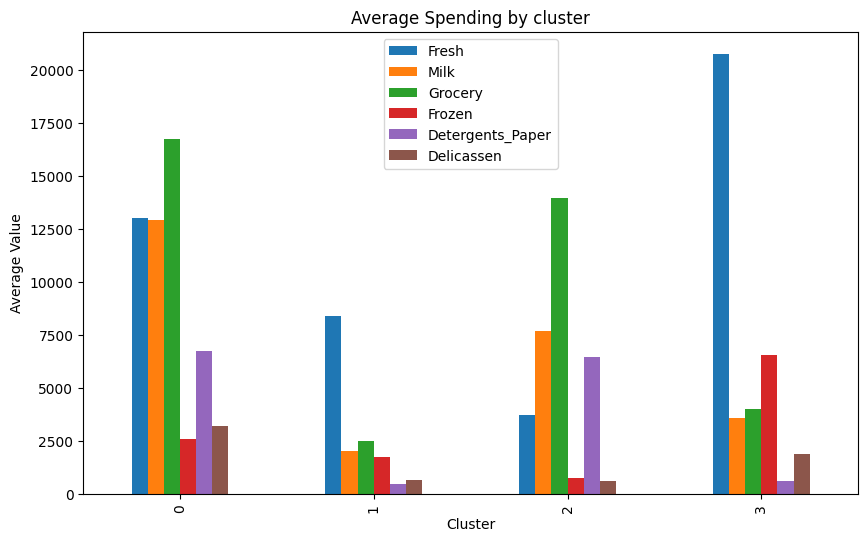

In [2057]:
ax = average_spending_df.plot(kind='bar', figsize=(10,6))
plt.title("Average Spending by cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Value")

- Cluster 0: Most spendings are in Grocery, followed by Fresh, Milk, Detergents_Paper and  Delicatessen, Lowest spending in Frozen.
- Cluster 1: Most spendings are in Fresh, followed by Grocery, Milk, Frozen and Delicatessen, Lowest spending in Detergents_Paper.
- Cluster 2: Most spendings are in Grocery, followed by Fresh and Milk, Detergents_Paper and Frozen  Lowest spending in Delicatessen.
- Cluster 3: Most spendings are in Fresh, followed by Frozen, Grocery, Milk and Delicatessen, Lowest spending in Detergents_Paper.

In [2058]:
count_group = customers.groupby(['Channel', 'Cluster']).size().reset_index(name='Count')
count_group

,Channel,Cluster,Count
0,1,0,16
1,1,1,148
2,1,2,18
3,1,3,116
4,2,0,79
5,2,1,1
6,2,2,57
7,2,3,5


Text(0.5, 1.0, 'Channel 2 (Retail) Cluster distribution')

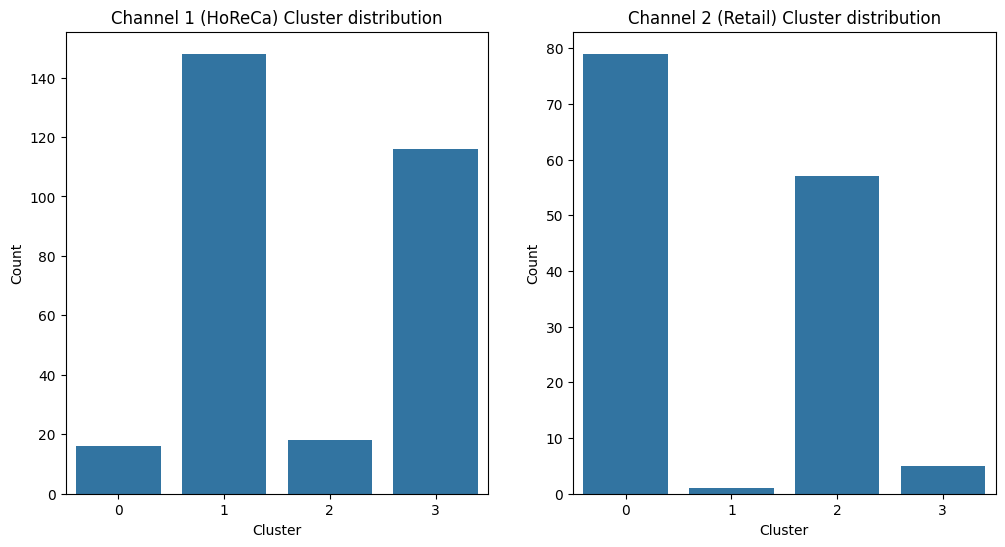

In [2059]:
fig, axes = plt.subplots(1,2, figsize=(12,6))
axes = axes.flatten()

channel_1 = count_group[count_group["Channel"] == 1]
sns.barplot(channel_1, x= channel_1["Cluster"], y=channel_1["Count"], ax=axes[0])
axes[0].set_title("Channel 1 (HoReCa) Cluster distribution")

channel_2 = count_group[count_group["Channel"] == 2]
sns.barplot(channel_2, x= channel_2["Cluster"], y=channel_2["Count"], ax=axes[1])
axes[1].set_title("Channel 2 (Retail) Cluster distribution")

# Conclusion

Horeca Spendings are mostly in cluster 1 and 3, which means most spendings are in Fresh. Lowest in Detergents_Paper.
Retail Spendings are mostly in cluster 0 and 2, which means most spending are in Grocery, lowest in Frozen and Delicatessen.

# Action

Business can promote more Fresh products for HoReCA customers, probably add more discounts and promotions. Retail customers spend more on Grocery, so business should promote more on Grocery products for Retail customers.